# Notebook 03 — Baseline modeling and evaluation

This notebook evaluates whether the morphology features extracted in Notebook 02 contain useful signal for binary ECG-only classification of Brugada-positive versus non-Brugada records. The project target is kept fixed: `brugada = 0` is treated as non-Brugada, while `brugada > 0` is treated as Brugada positive.

The analysis is intentionally framed as a first baseline rather than an optimized model search. Two feature sets are compared: right-precordial morphology from V1–V2 and the same representation extended to V1–V3. Models are evaluated with 5-fold stratified cross-validation using balanced accuracy as the main metric, with recall, precision, F1 and ROC-AUC reported to characterize the trade-off between false negatives and false positives.

## 1. Imports and configuration

This section defines the modeling environment, input feature tables and output paths. Processed ECG features are read from `data/processed/`, while model-evaluation artifacts are saved to `results/`.

In [32]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
N_JOBS = -1

DATA_DIR = "../data/processed"
RESULTS_DIR = "../results"

os.makedirs(RESULTS_DIR, exist_ok=True)

FEATURES_PATH = os.path.join(DATA_DIR, "ecg_morphology_features.csv")
QC_PATH = os.path.join(DATA_DIR, "ecg_morphology_feature_qc.csv")

BASELINE_RESULTS_PATH = os.path.join(RESULTS_DIR, "baseline_cv_results.csv")
FEATURE_SET_COMPARISON_PATH = os.path.join(RESULTS_DIR, "baseline_feature_set_comparison.csv")
ERROR_ANALYSIS_PATH = os.path.join(RESULTS_DIR, "baseline_oof_error_analysis.csv")

## 2. Load data

The morphology feature table is the modeling input. The QC table is loaded only for inspection and traceability; QC variables are not used as predictors in this baseline.

In [33]:
features = pd.read_csv(FEATURES_PATH)
qc = pd.read_csv(QC_PATH)

print("Features shape:", features.shape)
print("QC shape:", qc.shape)


Features shape: (361, 108)
QC shape: (363, 67)


In [34]:
features.head()

,patient_id,brugada,brugada_syndrome,basal_pattern,sudden_death,fs,record_base,r_detection_lead,morphology_highpass_cutoff_hz,morphology_lowpass_cutoff_hz,...,v3_st_slope_j040_j120_mV_per_s,v3_coved_proxy_j040_j120_mV,v3_true_st_max_j000_j120_mV,v3_st_area_j000_j120_mV_s,v3_st_max_time_j000_j120_ms,v3_st_curv_j000_j120_mV,v3_st_peak_to_late_drop_j000_j120_mV,v3_t_curv_j120_r320_mV,v3_t_min_j120_r320_mV,v3_coved_shape_index
0,188981,1,1,1,0,100.0,../data/raw/brugada-huca-1.0.0\files\188981\18...,II,NaN,40,...,0.684728,-0.054778,0.178614,0.016023,120.0,-0.017130,0.000000,0.173176,0.149420,0.178614
1,251972,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\251972\25...,II,NaN,40,...,3.332361,-0.266589,0.405244,0.022457,120.0,-0.010585,0.000000,0.226272,0.073189,0.405244
2,265715,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\265715\26...,II,NaN,40,...,1.465296,-0.117224,0.070007,-0.002898,120.0,-0.003539,0.000000,0.308683,-0.051861,0.121868
3,267628,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\267628\26...,II,NaN,40,...,1.432853,-0.114628,0.027288,-0.007477,120.0,0.005207,0.000000,0.352449,-0.010030,0.037318
4,286830,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\286830\28...,II,NaN,40,...,0.894936,-0.071595,0.066527,0.002166,110.0,-0.006952,-0.014401,0.111423,-0.017679,0.084207


In [35]:
qc.head()

,metadata_index,patient_id,status,error,fs,record_base,r_detection_lead,morphology_highpass_cutoff_hz,morphology_lowpass_cutoff_hz,baseline_reference_window_start_s,...,j_n_leads_used,j_leads_used,t_curvature_left_offset_from_j_s,t_curvature_right_time_from_r_s,high_hr_flag,short_cycle_flag,low_beat_count_flag,high_overlap_flag,jpoint_unreliable_flag,jpoint_timing_flag
0,0,188981,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\188981\18...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,False,False
1,1,251972,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\251972\25...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,False,False
2,2,265715,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\265715\26...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,False,False
3,3,267628,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\267628\26...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,True,True
4,4,267630,failed,Fewer than 3 valid beats detected.,100.0,../data/raw/brugada-huca-1.0.0\files\267630\26...,II,NaN,40,-0.2,...,NaN,NaN,0.12,0.32,False,True,True,True,False,False


## 3. Binary target

The binary target follows the project definition established in Notebook 01: all records with `brugada > 0` are treated as Brugada positive, including flecainide-confirmed positive cases. This keeps the classification task aligned with the intended ECG-only screening question.

In [36]:
features["brugada_syndrome"] = (features["brugada"] > 0).astype(int)

target_counts = (
    features["brugada_syndrome"]
    .value_counts()
    .sort_index()
    .rename(index={0: "non-Brugada", 1: "Brugada positive"})
)

display(target_counts)

print(f"Positive class proportion: {features['brugada_syndrome'].mean():.3f}")
print(f"Negative class proportion: {1 - features['brugada_syndrome'].mean():.3f}")

brugada_syndrome
non-Brugada         287
Brugada positive     74
Name: count, dtype: int64

Positive class proportion: 0.205
Negative class proportion: 0.795


## 4. Feature sets

The baseline uses 16 morphology features per lead, derived from the representative median beat and focused on QRS, ST-segment and T-wave morphology. Two predefined feature sets are evaluated: V1–V2, which captures the core right-precordial leads, and V1–V3, which adds adjacent right-precordial context without expanding to the full 12-lead ECG.

In [37]:
BASE_MORPHOLOGY_FEATURES = [
    "r_amp_mV",
    "s_amp_mV",
    "st_j000_mV",
    "st_j040_mV",
    "st_j080_mV",
    "st_j120_mV",
    "true_st_max_j000_j120_mV",
    "st_max_time_j000_j120_ms",
    "st_peak_to_late_drop_j000_j120_mV",
    "st_slope_j040_j120_mV_per_s",
    "st_area_j000_j120_mV_s",
    "st_curv_j000_j120_mV",
    "coved_proxy_j040_j120_mV",
    "coved_shape_index",
    "t_curv_j120_r320_mV",
    "t_min_j120_r320_mV",
]


In [38]:
def make_lead_feature_columns(leads, base_features):
    return [
        f"{lead.lower()}_{feature}"
        for lead in leads
        for feature in base_features
    ]

In [39]:
v1_v2_features = make_lead_feature_columns(
    leads=["V1", "V2"],
    base_features=BASE_MORPHOLOGY_FEATURES,
)

v1_v3_features = make_lead_feature_columns(
    leads=["V1", "V2", "V3"],
    base_features=BASE_MORPHOLOGY_FEATURES,
)

feature_sets = {
    "V1-V2": v1_v2_features,
    "V1-V3": v1_v3_features,
}

all_model_features = [
    feature
    for feature_columns in feature_sets.values()
    for feature in feature_columns
]

all_model_features = sorted(set(all_model_features))

required_columns = [
    "patient_id",
    "brugada",
    "brugada_syndrome",
    "basal_pattern",
] + all_model_features

missing_columns = [col for col in required_columns if col not in features.columns]
assert not missing_columns, f"Missing expected columns: {missing_columns}"

for name, columns in feature_sets.items():
    print(f"{name} features: {len(columns)}")

assert len(feature_sets["V1-V2"]) == 32
assert len(feature_sets["V1-V3"]) == 48


V1-V2 features: 32
V1-V3 features: 48


The expected dimensions are 32 features for V1–V2 and 48 features for V1–V3. These counts are checked before modeling to ensure that the intended feature sets are being evaluated.

## 5. Modeling dataset

The same records are used for both feature sets. Since Notebook 01 and Notebook 02 already established the expected dataset structure, this section keeps only essential checks for missing or non-finite modeling values.

In [40]:
model_data = features.dropna(
    subset=all_model_features + ["brugada_syndrome"]
).copy()

assert len(model_data) == len(features), "Unexpected missing values in modeling columns."
assert np.isfinite(model_data[all_model_features].to_numpy()).all(), "Unexpected infinite values in modeling columns."

print("Records:", len(model_data))
print("Positive records:", int(model_data["brugada_syndrome"].sum()))
print("Negative records:", int((model_data["brugada_syndrome"] == 0).sum()))


Records: 361
Positive records: 74
Negative records: 287


In [41]:
model_data["brugada_syndrome"].value_counts().sort_index()


brugada_syndrome
0    287
1     74
Name: count, dtype: int64

## 6. Baseline models

The main reference models are simple, regularized or low-capacity classifiers suitable for a small tabular biomedical dataset. More flexible nonlinear models are included as comparisons, but they are interpreted cautiously because they can overfit when the number of records is limited.

In [42]:
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier(
            class_weight="balanced",
        )),
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=20000,
            dual=False,
            random_state=RANDOM_STATE,
        )),
    ]),

    "LDA Shrinkage": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto",
        )),
    ]),

    "Gaussian NB": GaussianNB(),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
        )),
    ]),

    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}


## 7. Cross-validation and metrics

Five-fold stratified cross-validation is used to preserve the class ratio in each fold and avoid relying on a single small hold-out split. Balanced accuracy is the primary metric because the dataset is imbalanced; recall and precision are inspected separately to understand the false-negative and false-positive behavior.

In [43]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "roc_auc": "roc_auc",
}


In [44]:
def evaluate_feature_set(df, feature_set_name, feature_columns, models, cv, scoring):
    X = df[feature_columns]
    y = df["brugada_syndrome"].astype(int)

    rows = []

    for model_name, model in models.items():
        cv_results = cross_validate(
            estimator=model,
            X=X,
            y=y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=N_JOBS,
        )

        row = {
            "feature_set": feature_set_name,
            "model": model_name,
            "n_records": len(y),
            "n_positive": int(y.sum()),
            "n_negative": int((y == 0).sum()),
            "n_features": len(feature_columns),
        }

        for metric_name in scoring.keys():
            train_scores = cv_results[f"train_{metric_name}"]
            test_scores = cv_results[f"test_{metric_name}"]

            row[f"train_{metric_name}_mean"] = train_scores.mean()
            row[f"train_{metric_name}_std"] = train_scores.std()
            row[f"test_{metric_name}_mean"] = test_scores.mean()
            row[f"test_{metric_name}_std"] = test_scores.std()

        row["gap_balanced_accuracy"] = (
            row["train_balanced_accuracy_mean"] - row["test_balanced_accuracy_mean"]
        )
        row["gap_roc_auc"] = row["train_roc_auc_mean"] - row["test_roc_auc_mean"]

        rows.append(row)

    return pd.DataFrame(rows)


## 8. Run baseline evaluation

Each model is evaluated on both feature sets with the same cross-validation scheme and metrics. Train scores are also stored to estimate the train/test gap as a simple overfitting diagnostic.

In [45]:
results = pd.concat(
    [
        evaluate_feature_set(
            df=model_data,
            feature_set_name=name,
            feature_columns=columns,
            models=models,
            cv=cv,
            scoring=scoring,
        )
        for name, columns in feature_sets.items()
    ],
    ignore_index=True,
)

results.head()


,feature_set,model,n_records,n_positive,n_negative,n_features,train_balanced_accuracy_mean,train_balanced_accuracy_std,test_balanced_accuracy_mean,test_balanced_accuracy_std,...,train_recall_mean,train_recall_std,test_recall_mean,test_recall_std,train_roc_auc_mean,train_roc_auc_std,test_roc_auc_mean,test_roc_auc_std,gap_balanced_accuracy,gap_roc_auc
0,V1-V2,Dummy Classifier,361,74,287,32,0.500000,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000
1,V1-V2,Logistic Regression,361,74,287,32,0.884779,0.021154,0.848459,0.046403,...,0.881921,0.027353,0.825714,0.107395,0.948296,0.007496,0.906964,0.021026,0.036319,0.041332
2,V1-V2,Ridge Classifier,361,74,287,32,0.882156,0.014063,0.841546,0.040715,...,0.851412,0.019209,0.798095,0.110476,0.946687,0.007459,0.906003,0.038428,0.040610,0.040684
3,V1-V2,Linear SVM,361,74,287,32,0.893806,0.012897,0.840359,0.061123,...,0.888644,0.022096,0.799048,0.151198,0.955643,0.009813,0.900508,0.031211,0.053447,0.055135
4,V1-V2,LDA Shrinkage,361,74,287,32,0.819290,0.017335,0.794301,0.113407,...,0.665593,0.035600,0.620000,0.232475,0.930578,0.008416,0.908756,0.045544,0.024989,0.021821


## 9. Main results

The main table is sorted by cross-validated balanced accuracy and then ROC-AUC. The linear/simple subset is shown separately because these models are the most defensible baseline reference for this dataset size.

In [46]:
main_cols = [
    "feature_set",
    "model",
    "n_records",
    "n_positive",
    "n_features",
    "test_balanced_accuracy_mean",
    "test_balanced_accuracy_std",
    "test_f1_mean",
    "test_precision_mean",
    "test_recall_mean",
    "test_roc_auc_mean",
    "gap_balanced_accuracy",
    "gap_roc_auc",
]

results_main = (
    results[main_cols]
    .sort_values(
        by=["test_balanced_accuracy_mean", "test_roc_auc_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

results_main.round(3)


,feature_set,model,n_records,n_positive,n_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_mean,test_precision_mean,test_recall_mean,test_roc_auc_mean,gap_balanced_accuracy,gap_roc_auc
0,V1-V3,Logistic Regression,361,74,48,0.862,0.048,0.732,0.653,0.839,0.916,0.048,0.047
1,V1-V2,Logistic Regression,361,74,32,0.848,0.046,0.708,0.628,0.826,0.907,0.036,0.041
2,V1-V3,Linear SVM,361,74,48,0.845,0.050,0.709,0.635,0.812,0.905,0.069,0.063
3,V1-V2,Ridge Classifier,361,74,32,0.842,0.041,0.709,0.649,0.798,0.906,0.041,0.041
4,V1-V2,Linear SVM,361,74,32,0.840,0.061,0.701,0.640,0.799,0.901,0.053,0.055
5,V1-V3,Ridge Classifier,361,74,48,0.839,0.066,0.705,0.635,0.796,0.918,0.060,0.043
6,V1-V2,RBF SVM,361,74,32,0.827,0.044,0.718,0.716,0.730,0.893,0.102,0.078
7,V1-V3,LDA Shrinkage,361,74,48,0.805,0.096,0.706,0.808,0.649,0.921,0.030,0.024
8,V1-V2,Gradient Boosting,361,74,32,0.800,0.067,0.707,0.845,0.635,0.894,0.200,0.106
9,V1-V2,LDA Shrinkage,361,74,32,0.794,0.113,0.687,0.832,0.620,0.909,0.025,0.022


In [47]:
linear_baseline_models = [
    "Logistic Regression",
    "Ridge Classifier",
    "Linear SVM",
    "LDA Shrinkage",
    "Gaussian NB",
]

linear_results = (
    results_main[results_main["model"].isin(linear_baseline_models)]
    .sort_values(
        by=["test_balanced_accuracy_mean", "test_roc_auc_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

linear_results.round(3)


,feature_set,model,n_records,n_positive,n_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_mean,test_precision_mean,test_recall_mean,test_roc_auc_mean,gap_balanced_accuracy,gap_roc_auc
0,V1-V3,Logistic Regression,361,74,48,0.862,0.048,0.732,0.653,0.839,0.916,0.048,0.047
1,V1-V2,Logistic Regression,361,74,32,0.848,0.046,0.708,0.628,0.826,0.907,0.036,0.041
2,V1-V3,Linear SVM,361,74,48,0.845,0.050,0.709,0.635,0.812,0.905,0.069,0.063
3,V1-V2,Ridge Classifier,361,74,32,0.842,0.041,0.709,0.649,0.798,0.906,0.041,0.041
4,V1-V2,Linear SVM,361,74,32,0.840,0.061,0.701,0.640,0.799,0.901,0.053,0.055
5,V1-V3,Ridge Classifier,361,74,48,0.839,0.066,0.705,0.635,0.796,0.918,0.060,0.043
6,V1-V3,LDA Shrinkage,361,74,48,0.805,0.096,0.706,0.808,0.649,0.921,0.030,0.024
7,V1-V2,LDA Shrinkage,361,74,32,0.794,0.113,0.687,0.832,0.620,0.909,0.025,0.022
8,V1-V2,Gaussian NB,361,74,32,0.786,0.049,0.637,0.599,0.702,0.873,0.023,0.020
9,V1-V3,Gaussian NB,361,74,48,0.773,0.065,0.624,0.614,0.661,0.854,0.030,0.030


## 10. V1–V2 vs V1–V3 comparison

This comparison tests whether adding V3 provides useful context beyond V1–V2. The goal is not only to identify the best feature set, but also to check whether the gain from the extra lead is consistent across model families.

In [48]:
comparison_bal_acc = results.pivot(
    index="model",
    columns="feature_set",
    values="test_balanced_accuracy_mean",
)

comparison_bal_acc["delta_V1_V3_minus_V1_V2"] = (
    comparison_bal_acc["V1-V3"] - comparison_bal_acc["V1-V2"]
)

comparison_bal_acc = comparison_bal_acc.sort_values(
    "delta_V1_V3_minus_V1_V2",
    ascending=False,
)

comparison_bal_acc.round(3)


feature_set,V1-V2,V1-V3,delta_V1_V3_minus_V1_V2
model,,,
Logistic Regression,0.848,0.862,0.014
LDA Shrinkage,0.794,0.805,0.011
Linear SVM,0.840,0.845,0.005
Random Forest,0.739,0.741,0.002
Dummy Classifier,0.500,0.500,0.000
Ridge Classifier,0.842,0.839,-0.003
Extra Trees,0.754,0.742,-0.012
Gaussian NB,0.786,0.773,-0.013
Gradient Boosting,0.800,0.785,-0.015


In [49]:
comparison_auc = results.pivot(
    index="model",
    columns="feature_set",
    values="test_roc_auc_mean",
)

comparison_auc["delta_V1_V3_minus_V1_V2"] = (
    comparison_auc["V1-V3"] - comparison_auc["V1-V2"]
)

comparison_auc = comparison_auc.sort_values(
    "delta_V1_V3_minus_V1_V2",
    ascending=False,
)

comparison_auc.round(3)


feature_set,V1-V2,V1-V3,delta_V1_V3_minus_V1_V2
model,,,
LDA Shrinkage,0.909,0.921,0.013
Ridge Classifier,0.906,0.918,0.012
Logistic Regression,0.907,0.916,0.009
Random Forest,0.877,0.882,0.005
Linear SVM,0.901,0.905,0.004
RBF SVM,0.893,0.893,0.000
Dummy Classifier,0.500,0.500,0.000
Extra Trees,0.892,0.891,-0.001
KNN,0.853,0.851,-0.001


In [50]:
comparison = (
    comparison_bal_acc[["V1-V2", "V1-V3", "delta_V1_V3_minus_V1_V2"]]
    .rename(columns={
        "V1-V2": "balanced_accuracy_V1_V2",
        "V1-V3": "balanced_accuracy_V1_V3",
        "delta_V1_V3_minus_V1_V2": "delta_balanced_accuracy",
    })
    .join(
        comparison_auc[["V1-V2", "V1-V3", "delta_V1_V3_minus_V1_V2"]]
        .rename(columns={
            "V1-V2": "roc_auc_V1_V2",
            "V1-V3": "roc_auc_V1_V3",
            "delta_V1_V3_minus_V1_V2": "delta_roc_auc",
        })
    )
    .reset_index()
)

comparison.round(3)


feature_set,model,balanced_accuracy_V1_V2,balanced_accuracy_V1_V3,delta_balanced_accuracy,roc_auc_V1_V2,roc_auc_V1_V3,delta_roc_auc
0,Logistic Regression,0.848,0.862,0.014,0.907,0.916,0.009
1,LDA Shrinkage,0.794,0.805,0.011,0.909,0.921,0.013
2,Linear SVM,0.840,0.845,0.005,0.901,0.905,0.004
3,Random Forest,0.739,0.741,0.002,0.877,0.882,0.005
4,Dummy Classifier,0.500,0.500,0.000,0.500,0.500,0.000
5,Ridge Classifier,0.842,0.839,-0.003,0.906,0.918,0.012
6,Extra Trees,0.754,0.742,-0.012,0.892,0.891,-0.001
7,Gaussian NB,0.786,0.773,-0.013,0.873,0.854,-0.019
8,Gradient Boosting,0.800,0.785,-0.015,0.894,0.883,-0.012
9,RBF SVM,0.827,0.785,-0.042,0.893,0.893,0.000


## 11. Simple visualization

The plot summarizes cross-validated balanced accuracy for each model and feature set. It is used as a quick visual check of model ranking and of the effect of adding V3.

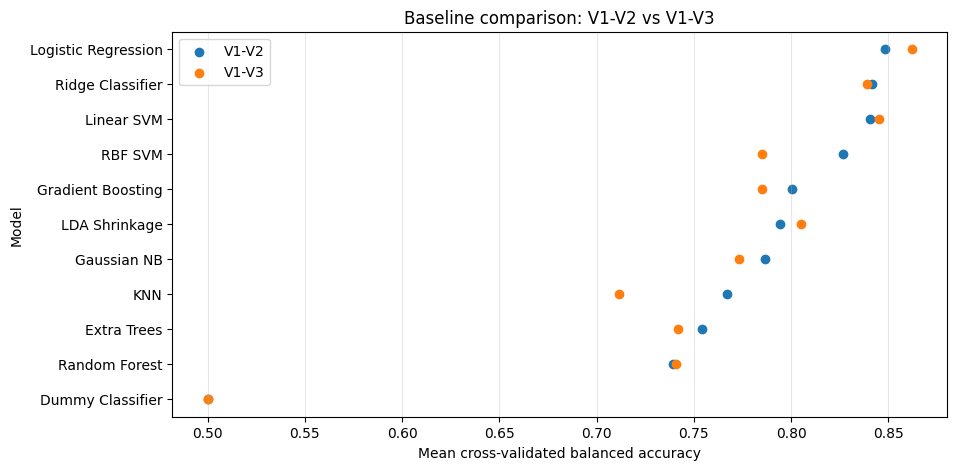

In [51]:
plot_data = results.copy()

plt.figure(figsize=(10, 5))

for feature_set in ["V1-V2", "V1-V3"]:
    subset = plot_data[plot_data["feature_set"] == feature_set]
    subset = subset.sort_values("test_balanced_accuracy_mean", ascending=True)
    plt.scatter(
        subset["test_balanced_accuracy_mean"],
        subset["model"],
        label=feature_set,
    )

plt.xlabel("Mean cross-validated balanced accuracy")
plt.ylabel("Model")
plt.title("Baseline comparison: V1-V2 vs V1-V3")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()


## 12. Save outputs

The cross-validation results, feature-set comparison and out-of-fold error analysis are saved to `results/`. This keeps modeling outputs separate from processed data generated by earlier notebooks.

In [52]:
results.to_csv(BASELINE_RESULTS_PATH, index=False)
comparison.to_csv(FEATURE_SET_COMPARISON_PATH, index=False)

print("Saved:", BASELINE_RESULTS_PATH)
print("Saved:", FEATURE_SET_COMPARISON_PATH)


Saved: ../results\baseline_cv_results.csv
Saved: ../results\baseline_feature_set_comparison.csv


## 13. Interpretation notes

The baseline should be interpreted primarily through balanced accuracy, ROC-AUC, recall, precision and the train/test gap. For a screening-oriented task, false negatives are especially important, but precision and specificity still matter because excessive false positives would limit practical usefulness.

In [53]:
best_overall = results_main.iloc[0]

print("Best overall model by balanced accuracy:")
print("Feature set:", best_overall["feature_set"])
print("Model:", best_overall["model"])
print("Balanced accuracy:", round(best_overall["test_balanced_accuracy_mean"], 3))
print("ROC-AUC:", round(best_overall["test_roc_auc_mean"], 3))
print("Recall:", round(best_overall["test_recall_mean"], 3))
print("Precision:", round(best_overall["test_precision_mean"], 3))
print("Balanced accuracy gap:", round(best_overall["gap_balanced_accuracy"], 3))


Best overall model by balanced accuracy:
Feature set: V1-V3
Model: Logistic Regression
Balanced accuracy: 0.862
ROC-AUC: 0.916
Recall: 0.839
Precision: 0.653
Balanced accuracy gap: 0.048


In [54]:
best_linear = linear_results.iloc[0]

print("Best linear/simple baseline by balanced accuracy:")
print("Feature set:", best_linear["feature_set"])
print("Model:", best_linear["model"])
print("Balanced accuracy:", round(best_linear["test_balanced_accuracy_mean"], 3))
print("ROC-AUC:", round(best_linear["test_roc_auc_mean"], 3))
print("Recall:", round(best_linear["test_recall_mean"], 3))
print("Precision:", round(best_linear["test_precision_mean"], 3))
print("Balanced accuracy gap:", round(best_linear["gap_balanced_accuracy"], 3))


Best linear/simple baseline by balanced accuracy:
Feature set: V1-V3
Model: Logistic Regression
Balanced accuracy: 0.862
ROC-AUC: 0.916
Recall: 0.839
Precision: 0.653
Balanced accuracy gap: 0.048


## 14. Brief out-of-fold error analysis

Out-of-fold predictions from the best linear/simple baseline are used to identify records that were misclassified without training and evaluating on the same fold. This provides a practical list of false negatives and false positives for later visual ECG review.

In [55]:
best_error_model = linear_results.iloc[0]

error_feature_set = best_error_model["feature_set"]
error_model_name = best_error_model["model"]
error_feature_columns = feature_sets[error_feature_set]
error_model = models[error_model_name]

print("Model selected for error analysis:")
print("Feature set:", error_feature_set)
print("Model:", error_model_name)
print("Features:", len(error_feature_columns))


Model selected for error analysis:
Feature set: V1-V3
Model: Logistic Regression
Features: 48


In [56]:
X_error = model_data[error_feature_columns]
y_error = model_data["brugada_syndrome"].astype(int)

oof_pred = cross_val_predict(
    estimator=error_model,
    X=X_error,
    y=y_error,
    cv=cv,
    method="predict",
    n_jobs=N_JOBS,
)

cm = confusion_matrix(y_error, oof_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["actual_non_Brugada", "actual_Brugada_positive"],
    columns=["pred_non_Brugada", "pred_Brugada_positive"],
)

display(cm_df)

print(classification_report(
    y_error,
    oof_pred,
    target_names=["non-Brugada", "Brugada positive"],
    zero_division=0,
))

,pred_non_Brugada,pred_Brugada_positive
actual_non_Brugada,254,33
actual_Brugada_positive,12,62


                  precision    recall  f1-score   support

     non-Brugada       0.95      0.89      0.92       287
Brugada positive       0.65      0.84      0.73        74

        accuracy                           0.88       361
       macro avg       0.80      0.86      0.83       361
    weighted avg       0.89      0.88      0.88       361



In [57]:
error_table = model_data.copy()

error_table["y_true"] = y_error.values
error_table["y_pred_oof"] = oof_pred

error_table["error_type"] = "correct"
error_table.loc[
    (error_table["y_true"] == 0) & (error_table["y_pred_oof"] == 1),
    "error_type"
] = "false_positive"

error_table.loc[
    (error_table["y_true"] == 1) & (error_table["y_pred_oof"] == 0),
    "error_type"
] = "false_negative"

error_summary = error_table["error_type"].value_counts()

error_summary


error_type
correct           316
false_positive     33
false_negative     12
Name: count, dtype: int64

In [58]:
error_view_columns = [
    "patient_id",
    "brugada",
    "basal_pattern",
    "y_true",
    "y_pred_oof",
    "error_type",
]

errors_only = (
    error_table.loc[error_table["error_type"] != "correct", error_view_columns]
    .sort_values(["error_type", "patient_id"])
    .reset_index(drop=True)
)

print("Number of errors:", len(errors_only))

errors_only

Number of errors: 45


,patient_id,brugada,basal_pattern,y_true,y_pred_oof,error_type
0,319150,1,0,1,0,false_negative
1,419960,1,0,1,0,false_negative
2,460919,2,0,1,0,false_negative
3,482516,1,0,1,0,false_negative
4,519687,1,0,1,0,false_negative
5,878765,1,1,1,0,false_negative
6,972048,1,0,1,0,false_negative
7,1092237,1,0,1,0,false_negative
8,1254267,1,1,1,0,false_negative
9,1370418,1,0,1,0,false_negative


In [59]:
error_table.to_csv(ERROR_ANALYSIS_PATH, index=False)

print("Saved:", ERROR_ANALYSIS_PATH)


Saved: ../results\baseline_oof_error_analysis.csv


False negatives are prioritized for manual inspection because they correspond to Brugada-positive records predicted as non-Brugada. False positives are also informative because they may reveal non-Brugada ECGs with right-precordial morphology that resembles the positive class or exposes limitations of the current features.

## 15. Limitations and next steps

This notebook is a fixed baseline, not an optimized model-selection study. Some preprocessing and feature-extraction choices remain empirical and should be tested later through a separate sensitivity-analysis or nested-validation workflow. The immediate next step is to inspect the out-of-fold false negatives and false positives before adding more complex models or tuning pipeline parameters.